In [162]:
import pandas as pd;
import matplotlib.pyplot as plt;

In [163]:
customers = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\olist_customers_dataset.csv");
products = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\olist_products_dataset.csv");
sellers = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\olist_sellers_dataset.csv")
orders = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\olist_orders_dataset.csv")
order_reviews = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\olist_order_reviews_dataset.csv")
order_payments = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\olist_order_payments_dataset.csv")
order_items = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\olist_order_items_dataset.csv")
geolocation = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\olist_geolocation_dataset.csv")
product_category = pd.read_csv(r"C:\Users\ASHA\Downloads\power_bi\olist_dataset\product_category_name_translation.csv")

In [190]:
print(analysis_df.isnull().sum().sort_values(ascending=False))

review_comment_title             104418
review_comment_message            68628
order_delivered_customer_date      2588
product_category_name              1709
product_name_lenght                1709
product_photos_qty                 1709
product_description_lenght         1709
order_delivered_carrier_date       1254
review_creation_date                978
review_score                        978
review_id                           978
review_answer_timestamp             978
product_height_cm                    20
product_weight_g                     20
product_length_cm                    20
product_width_cm                     20
order_approved_at                    15
payment_sequential                    3
payment_value                         3
payment_installments                  3
payment_type                          3
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_id                              0


In [191]:
print('customers', customers.duplicated().sum())
print('products', products.duplicated().sum())
print('sellers',sellers.duplicated().sum())

customers 0
products 0
sellers 0


In [192]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns :
    orders[col] = pd.to_datetime(orders[col]);

In [193]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [194]:
print('Price',order_items['price'].describe())
print('Frieght value',order_items['freight_value'].describe())
print('Payment value',order_payments['payment_value'].describe())
print('Review score',order_reviews['review_score'].describe())

Price count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64
Frieght value count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64
Payment value count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64
Review score count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64


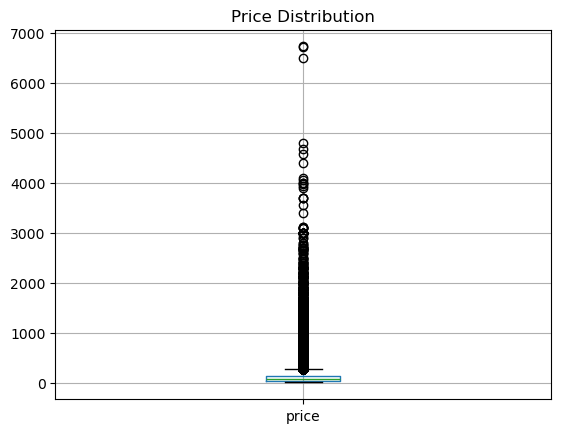

In [223]:
order_items.boxplot(column = 'price')
plt.title('Price Distribution')
plt.show()

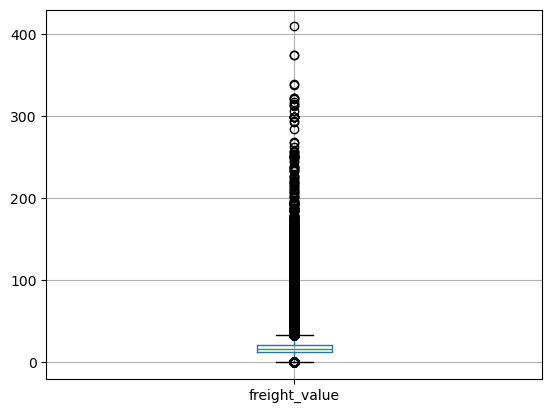

In [224]:
order_items.boxplot(column = 'freight_value')
plt.show()

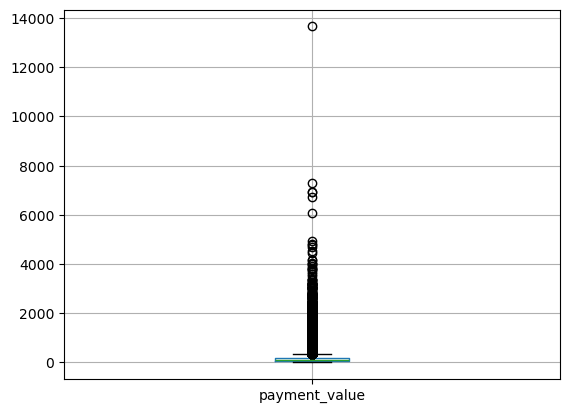

In [197]:
order_payments.boxplot(column = 'payment_value')
plt.show()

In [198]:
order_payments['payment_value'].nlargest(10)

52107    13664.08
34370     7274.88
41419     6929.31
49581     6922.21
85539     6726.66
62409     6081.54
43232     4950.34
70320     4809.44
6440      4764.34
67546     4681.78
Name: payment_value, dtype: float64

In [199]:
order_reviews['review_score'].nlargest


<bound method Series.nlargest of 0        4
1        5
2        5
3        5
4        5
        ..
99219    5
99220    5
99221    5
99222    4
99223    1
Name: review_score, Length: 99224, dtype: int64>

In [200]:
customers['customer_city'] = customers['customer_city'].str.strip()
customers['customer_city'] = customers['customer_state'].str.strip()

In [206]:
analysis_df = pd.merge(customers, orders, on='customer_id', how='inner')

analysis_df = pd.merge(analysis_df, order_items, on='order_id', how='inner')

analysis_df = pd.merge(analysis_df, products, on='product_id', how='inner')

analysis_df = pd.merge(analysis_df, order_payments, on='order_id', how='left')

analysis_df = pd.merge(analysis_df, order_reviews, on='order_id', how='left')

In [207]:
analysis_df.shape

(118310, 36)

In [208]:
analysis_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,SP,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,SP,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,SP,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,SP,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,SP,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52


In [209]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    118310 non-null  object        
 1   customer_unique_id             118310 non-null  object        
 2   customer_zip_code_prefix       118310 non-null  int64         
 3   customer_city                  118310 non-null  object        
 4   customer_state                 118310 non-null  object        
 5   order_id                       118310 non-null  object        
 6   order_status                   118310 non-null  object        
 7   order_purchase_timestamp       118310 non-null  datetime64[ns]
 8   order_approved_at              118295 non-null  datetime64[ns]
 9   order_delivered_carrier_date   117056 non-null  datetime64[ns]
 10  order_delivered_customer_date  115722 non-null  datetime64[ns]
 11  

In [210]:
analysis_df['order_status'].value_counts()

order_status
delivered      115723
shipped          1255
canceled          570
invoiced          376
processing        376
unavailable         7
approved            3
Name: count, dtype: int64

In [211]:
analysis_df['payment_type'].value_counts()

payment_type
credit_card    87258
boleto         23018
voucher         6332
debit_card      1699
Name: count, dtype: int64

In [212]:
numeric_columns = [
    'price',
    'freight_value',
    'payment_value', 
    'review_score'
];

In [213]:
print(analysis_df[numeric_columns].describe().round(2))

           price  freight_value  payment_value  review_score
count  118310.00      118310.00      118307.00     117332.00
mean      120.65          20.03         172.58          4.03
std       184.11          15.84         267.11          1.39
min         0.85           0.00           0.00          1.00
25%        39.90          13.08          60.85          4.00
50%        74.90          16.28         108.20          5.00
75%       134.90          21.18         189.26          5.00
max      6735.00         409.68       13664.08          5.00


In [214]:
print(analysis_df.shape)

(118310, 36)


In [215]:
analysis_df.select_dtypes(include = object).head

<bound method NDFrame.head of                              customer_id                customer_unique_id  \
0       06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1       18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2       4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3       b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4       4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                  ...                               ...   
118305  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
118306  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
118307  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
118308  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
118309  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

       customer_city customer_sta

In [216]:
analysis_df['product_category_name'] = (
    analysis_df['product_category_name']
    .str.strip()
    .str.lower()
)

In [217]:
analysis_df['customer_city'] = analysis_df['customer_city'].str.title()

In [218]:
text_columns = [
    'customer_city',
    'product_category_name'
]

for col in text_columns:
    analysis_df[col] = analysis_df[col].str.strip()

In [219]:
analysis_df['customer_city'] = (
    analysis_df['customer_city']
    .str.replace(r'\s+', ' ', regex=True)
)

In [220]:
analysis_df['shipping_limit_date'] = pd.to_datetime(analysis_df['shipping_limit_date'])
analysis_df['review_creation_date'] = pd.to_datetime(analysis_df['review_creation_date'])
analysis_df['review_answer_timestamp'] = pd.to_datetime(analysis_df['review_answer_timestamp'])
analysis_df['order_purchase_timestamp'] = pd.to_datetime(analysis_df['order_purchase_timestamp'])
analysis_df['order_approved_at'] = pd.to_datetime(analysis_df['order_approved_at'])
analysis_df['order_delivered_carrier_date'] = pd.to_datetime(analysis_df['order_delivered_carrier_date'])
analysis_df['order_delivered_customer_date'] = pd.to_datetime(analysis_df['order_delivered_customer_date'])
analysis_df['order_estimated_delivery_date'] = pd.to_datetime(analysis_df['order_estimated_delivery_date'])

In [221]:
analysis_df.shape
analysis_df.info()
analysis_df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    118310 non-null  object        
 1   customer_unique_id             118310 non-null  object        
 2   customer_zip_code_prefix       118310 non-null  int64         
 3   customer_city                  118310 non-null  object        
 4   customer_state                 118310 non-null  object        
 5   order_id                       118310 non-null  object        
 6   order_status                   118310 non-null  object        
 7   order_purchase_timestamp       118310 non-null  datetime64[ns]
 8   order_approved_at              118295 non-null  datetime64[ns]
 9   order_delivered_carrier_date   117056 non-null  datetime64[ns]
 10  order_delivered_customer_date  115722 non-null  datetime64[ns]
 11  

review_comment_title             104418
review_comment_message            68628
order_delivered_customer_date      2588
product_category_name              1709
product_name_lenght                1709
product_photos_qty                 1709
product_description_lenght         1709
order_delivered_carrier_date       1254
review_creation_date                978
review_score                        978
review_id                           978
review_answer_timestamp             978
product_height_cm                    20
product_weight_g                     20
product_length_cm                    20
product_width_cm                     20
order_approved_at                    15
payment_sequential                    3
payment_value                         3
payment_installments                  3
payment_type                          3
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_id                              0


In [222]:
print(analysis_df.duplicated().sum())

0
